# Importing Libraries and Functions

In [502]:
# Import libraries
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path
from adjustText import adjust_text

# Import functions from src/features.py
sys.path.append(
    str(Path().resolve().parent)
)

from src.features import (
    get_match_result,
    goal_diff,
    add_position_group,
    team_rating,
    assign_tournament_weight
)

# Load Data

In [503]:
# Load Cleaned Datasets
results = pd.read_csv("../data/processed/results_clean.csv")
wc2026_draw = pd.read_csv("../data/processed/wc2026_draw_clean.csv")
players = pd.read_csv("../data/processed/players_clean.csv")
elo_ratings = pd.read_csv("../data/processed/elo_clean.csv")
wc2026_matches = pd.read_csv("../data/processed/wc2026_matches.csv")

In [504]:
results["date"] = pd.to_datetime(results["date"])
elo_ratings["rank_date"] = pd.to_datetime(elo_ratings["rank_date"])

# Features
## Team Ratings 
### 1. Squad Rating
The average rating of the 26 person squad (the maximum number of players in a squad) for each country.

In [505]:
squad_requirements = { # General squad requirements
    "GK": 3,
    "DEF": 9,
    "MID": 7,
    "FWD": 7
}

# Generating squad ratings for all countries based on top players in each position group, with fill rating for missing players
squad_ratings = team_rating(players, requirements=squad_requirements, rating_name="squad_rating")
squad_ratings.sort_values(["avg_rating", "team_size"], ascending=[False, False])

,country,avg_rating,team_size,missing_players
0,France,84.307692,26,0
3,England,84.115385,26,0
4,Brazil,83.615385,26,0
1,Spain,83.538462,26,0
8,Germany,83.192308,26,0
6,Argentina,82.961538,26,0
10,Portugal,82.923077,26,0
7,Netherlands,81.615385,26,0
5,Belgium,80.076923,26,0
11,Uruguay,78.307692,26,0


### 2. Top 11 Rating

The average rating of the top 11 players in the squad for each country.

In [506]:
top11_requirements = { # 4-3-3 formation as estimate for starting 11 requirements
    "GK": 1,
    "DEF": 4,
    "MID": 3,
    "FWD": 3
}

# Generating top 11 ratings for all countries based on top players in each position group, with fill rating for missing players
top11_ratings = team_rating(players, requirements=top11_requirements, rating_name="top11_rating")
top11_ratings.sort_values(["avg_rating", "team_size"], ascending=[False, False])

,country,avg_rating,team_size,missing_players
0,France,86.272727,11,0
3,England,86.272727,11,0
4,Brazil,86.181818,11,0
8,Germany,85.636364,11,0
10,Portugal,85.454545,11,0
6,Argentina,85.272727,11,0
1,Spain,84.909091,11,0
7,Netherlands,83.272727,11,0
5,Belgium,82.363636,11,0
11,Uruguay,81.545455,11,0


## Elo Features

### Preparing the data for merging

In [507]:
# Standardising country names between results and elo datasets
country_map = {
    "Brunei Darussalam": "Brunei",
    "Chinese Taipei": "Taiwan",
    "Hong Kong, China": "Hong Kong",
    "Korea DPR": "North Korea",
    "Kyrgyz Republic": "Kyrgyzstan",
    "St Kitts and Nevis": "Saint Kitts and Nevis",
    "St Lucia": "Saint Lucia",
    "St Vincent and the Grenadines": "Saint Vincent and the Grenadines",
    "The Gambia": "Gambia",
    "US Virgin Islands": "United States Virgin Islands"
}

# Apply country name mapping to elo dataset
elo_ratings["country_full"] = elo_ratings["country_full"].replace(country_map)

In [508]:
# Filter results to only include matches between countries present in the Elo ratings dataset as some countries are obsolete and not present in elo dataset
valid_countries = set(elo_ratings["country_full"])
results = results[results["home_team"].isin(valid_countries) & results["away_team"].isin(valid_countries)]

In [509]:
# Checking for any remaining discrepancies in country names between results and elo datasets
results_countries = set(results["home_team"]).union(
    set(results["away_team"])
)

elo_countries = set(elo_ratings["country_full"])

print("In results but not elo:")
print(sorted(results_countries - elo_countries))

print("\nIn elo but not results:")
print(sorted(elo_countries - results_countries))

In results but not elo:
[]

In elo but not results:
['Netherlands Antilles', 'Serbia and Montenegro', 'Zaire']


In [510]:
# Sorting by date for good measure, though it should already be sorted
elo_ratings = elo_ratings.sort_values("rank_date")
results = results.sort_values("date")

# Home team Elo ratings
home_elo = elo_ratings.rename(columns={
    "country_full": "home_team",
    "total_points": "home_elo"
})
# Merge home team Elo ratings with results
results = pd.merge_asof(
    results.sort_values("date"),
    home_elo.sort_values("rank_date"),
    left_on="date",
    right_on="rank_date",
    by="home_team",
    direction="backward"
)

# Away team Elo ratings
away_elo = elo_ratings.rename(columns={
    "country_full": "away_team",
    "total_points": "away_elo"
})

# Merge away team Elo ratings with results
results = pd.merge_asof(
    results.sort_values("date"),
    away_elo.sort_values("rank_date"),
    left_on="date",
    right_on="rank_date",
    by="away_team",
    direction="backward"
)

### Creating Features

### 1. elo_diff feature

The difference in elo rating between home and away teams at the time of each match.

In [511]:
results["elo_diff"] = results["home_elo"] - results["away_elo"]

### 2. home_higher_elo feature

If the home_team has a higher elo rating than the away team, the value is 1. Else, 0.

In [512]:
results["home_higher_elo"] = (results["home_elo"] > results["away_elo"]).astype(int)

In [513]:
results[["date", "home_team", "away_team", "home_elo", "away_elo", "elo_diff", "home_higher_elo"]].sample(10)

,date,home_team,away_team,home_elo,away_elo,elo_diff,home_higher_elo
23308,2000-09-02,Bosnia and Herzegovina,Spain,452.00,743.00,-291.00,0
18593,1994-10-12,Turkey,Iceland,38.00,39.00,-1.00,0
17787,1993-06-09,Hong Kong,Lebanon,5.00,0.00,5.00,1
35005,2013-10-11,Sweden,Austria,836.00,639.00,197.00,1
43232,2023-06-18,Eswatini,Togo,1069.89,1129.81,-59.92,0
8593,1973-06-10,China PR,Pakistan,NaN,NaN,NaN,0
45846,2025-11-14,Comoros,Namibia,1180.18,1162.79,17.39,1
23346,2000-09-26,Saudi Arabia,Syria,507.00,417.00,90.00,1
9775,1976-08-14,Malaysia,Indonesia,NaN,NaN,NaN,0
18493,1994-09-02,Solomon Islands,Fiji,2.00,14.00,-12.00,0


## Recent Form Features

### 1. Win rate of the last 10 matches

In [514]:
# Creating home dataset
home_df = results[[
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score"
]].copy()

# Rename columns
home_df["team"] = home_df["home_team"]
home_df["opponent"] = home_df["away_team"]

# Add win column for home team
home_df["win"] = (
    home_df["home_score"]
    > home_df["away_score"]
).astype(int)

home_df = home_df[["date", "team", "opponent", "win"]]

In [515]:
# Creating away dataset
away_df = results[[
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score"
]].copy()

# Rename columns
away_df["team"] = away_df["away_team"]
away_df["opponent"] = away_df["home_team"]

# Add win column for away team
away_df["win"] = (
    away_df["away_score"]
    > away_df["home_score"]
).astype(int)

away_df = away_df[["date", "team", "opponent", "win"]]

In [516]:
team_matches = pd.concat([home_df, away_df])

team_matches = team_matches.sort_values(["team", "date"])

team_matches["recent_win_rate"] = (
    team_matches
    .groupby("team")["win"]
    .transform(
        lambda x:
        x.shift(1).rolling(10, min_periods=1).mean() # last 10 matches win rate, excluding current match
    )
)
team_matches

,date,team,opponent,win,recent_win_rate
2474,1941-08-10,Afghanistan,India,0,NaN
3283,1950-10-26,Afghanistan,Iran,0,0.0
3320,1951-03-07,Afghanistan,India,0,0.0
3322,1951-03-09,Afghanistan,Japan,0,0.0
3714,1954-05-04,Afghanistan,South Korea,0,0.0
...,...,...,...,...,...
45899,2025-11-17,Zimbabwe,Qatar,1,0.0
45997,2025-12-22,Zimbabwe,Egypt,0,0.1
46008,2025-12-26,Zimbabwe,Angola,0,0.1
46020,2025-12-29,Zimbabwe,South Africa,0,0.1


In [517]:
# Creating home team and away team recent win rate features by merging with results dataframe

# df of home team's recent form
home_form = team_matches[[
    "date",
    "team",
    "recent_win_rate"
]].rename(columns={
    "team": "home_team",
    "recent_win_rate": "home_recent_win_rate"
})

# df of away team's recent form
away_form = team_matches[[
    "date",
    "team",
    "recent_win_rate"
]].rename(columns={
    "team": "away_team",
    "recent_win_rate": "away_recent_win_rate"
})

# Merging home and away recent form features with results df
results = results.merge(
    home_form,
    on=["date", "home_team"],
    how="left"
)

results = results.merge(
    away_form,
    on=["date", "away_team"],
    how="left"
)

results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_result,...,country_abrv_y,away_elo,previous_points_y,rank_change_y,confederation_y,rank_date_y,elo_diff,home_higher_elo,home_recent_win_rate,away_recent_win_rate
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,draw,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0,NaN,NaN
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,home_win,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0,0.000000,0.000000
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,home_win,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0,0.000000,0.500000
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,draw,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0,0.333333,0.333333
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,home_win,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0,0.250000,0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46477,2026-03-31,Montenegro,Slovenia,2,3,Friendly,Podgorica,Montenegro,False,away_win,...,SVN,1447.31,1447.31,-2.0,UEFA,2026-01-19,-150.22,0,0.400000,0.300000
46478,2026-03-31,Morocco,Paraguay,2,1,Friendly,Lens,France,True,home_win,...,PAR,1501.50,1501.50,-1.0,CONMEBOL,2026-01-19,235.07,1,0.700000,0.400000
46479,2026-03-31,Haiti,Iceland,1,1,Friendly,Toronto,Canada,True,draw,...,ISL,1344.72,1344.72,0.0,UEFA,2026-01-19,-50.23,0,0.300000,0.300000
46480,2026-03-31,Niger,Togo,0,1,"Morocco, Capital of African Football",Casablanca,Morocco,True,away_win,...,TOG,1140.35,1140.35,0.0,CAF,2026-01-19,44.74,1,0.400000,0.200000


### 2. Average goals scored in the last 10 matches
### 3. Total goals scored in the last 10 matches
### 4. Total goals conceded in the last 10 matches

In [518]:
# Creating home team and away team average goals scored in the last 10 matches
home_matches = results[[
    "date",
    "home_team",
    "home_score",
    "away_score"
]].copy()

home_matches["team"] = home_matches["home_team"]
home_matches["goals_scored"] = home_matches["home_score"]
home_matches["goals_conceded"] = home_matches["away_score"]

away_matches = results[[
    "date",
    "away_team",
    "away_score",
    "home_score"
]].copy()

away_matches["team"] = away_matches["away_team"]
away_matches["goals_scored"] = away_matches["away_score"]
away_matches["goals_conceded"] = away_matches["home_score"]

# Combining home and away matches to calculate average goals scored in last 10 matches for each team
team_matches = pd.concat([
    home_matches[["date", "team", "goals_scored", "goals_conceded"]],
    away_matches[["date", "team", "goals_scored", "goals_conceded"]]
])

# Sorting by team and date to ensure correct order for rolling calculation
team_matches = team_matches.sort_values(["team", "date"])

# Rolling window calculation for average goals scored in last 10 matches, excluding current match
team_matches["avg_goals_last10"] = (
    team_matches
    .groupby("team")["goals_scored"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean())
)

# Rolling window calculation for total goals scored in last 10 matches, excluding current match
team_matches["total_goals_last10"] = (
    team_matches
    .groupby("team")["goals_scored"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).sum())  # sum instead of mean
)

# Rolling window calculation for total goals conceded in last 10 matches, excluding current match
team_matches["total_conceded_last10"] = (
    team_matches
    .groupby("team")["goals_conceded"]
    .transform(lambda x: x.shift(1).rolling(10, min_periods=1).sum())
)

team_matches

,date,team,goals_scored,goals_conceded,avg_goals_last10,total_goals_last10,total_conceded_last10
2580,1941-08-10,Afghanistan,1,3,NaN,NaN,NaN
3409,1950-10-26,Afghanistan,0,4,1.000000,1.0,3.0
3446,1951-03-07,Afghanistan,0,3,0.500000,1.0,7.0
3448,1951-03-09,Afghanistan,0,2,0.333333,1.0,10.0
3844,1954-05-04,Afghanistan,2,8,0.250000,1.0,12.0
...,...,...,...,...,...,...,...
46193,2025-11-17,Zimbabwe,2,1,0.600000,6.0,14.0
46291,2025-12-22,Zimbabwe,1,2,0.700000,7.0,13.0
46302,2025-12-26,Zimbabwe,1,1,0.600000,6.0,13.0
46314,2025-12-29,Zimbabwe,2,3,0.600000,6.0,13.0


In [519]:
# Merge back using original home/away context
home_goals = (
    home_matches[["date", "home_team"]]
    .merge(team_matches[["date", "team", "avg_goals_last10", "total_goals_last10", "total_conceded_last10"]],
           left_on=["date", "home_team"],
           right_on=["date", "team"],
           how="left")
    .drop_duplicates(subset=["date", "home_team"])
    .rename(columns={"avg_goals_last10": "home_avg_goals_last10", "total_goals_last10": "home_total_goals_last10", "total_conceded_last10": "home_total_conceded_last10"})
)

away_goals = (
    away_matches[["date", "away_team"]]
    .merge(team_matches[["date", "team", "avg_goals_last10", "total_goals_last10", "total_conceded_last10"]],
           left_on=["date", "away_team"],
           right_on=["date", "team"],
           how="left")
    .drop_duplicates(subset=["date", "away_team"])
    .rename(columns={"avg_goals_last10": "away_avg_goals_last10", "total_goals_last10": "away_total_goals_last10", "total_conceded_last10": "away_total_conceded_last10"})
)

results = results.merge(
    home_goals[["date", "home_team", "home_avg_goals_last10", "home_total_goals_last10", "home_total_conceded_last10"]],
    on=["date", "home_team"],
    how="left"
)

results = results.merge(
    away_goals[["date", "away_team", "away_avg_goals_last10", "away_total_goals_last10", "away_total_conceded_last10"]],
    on=["date", "away_team"],
    how="left"
)

results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_result,...,elo_diff,home_higher_elo,home_recent_win_rate,away_recent_win_rate,home_avg_goals_last10,home_total_goals_last10,home_total_conceded_last10,away_avg_goals_last10,away_total_goals_last10,away_total_conceded_last10
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,draw,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,home_win,...,NaN,0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,home_win,...,NaN,0,0.000000,0.500000,1.000000,2.0,4.0,2.000000,4.0,2.0
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,draw,...,NaN,0,0.333333,0.333333,1.666667,5.0,4.0,1.333333,4.0,5.0
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,home_win,...,NaN,0,0.250000,0.250000,1.500000,6.0,7.0,1.750000,7.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46477,2026-03-31,Montenegro,Slovenia,2,3,Friendly,Podgorica,Montenegro,False,away_win,...,-150.22,0,0.400000,0.300000,1.100000,11.0,19.0,0.700000,7.0,10.0
46478,2026-03-31,Morocco,Paraguay,2,1,Friendly,Lens,France,True,home_win,...,235.07,1,0.700000,0.400000,1.900000,19.0,4.0,1.100000,11.0,10.0
46479,2026-03-31,Haiti,Iceland,1,1,Friendly,Toronto,Canada,True,draw,...,-50.23,0,0.300000,0.300000,1.100000,11.0,11.0,1.800000,18.0,19.0
46480,2026-03-31,Niger,Togo,0,1,"Morocco, Capital of African Football",Casablanca,Morocco,True,away_win,...,44.74,1,0.400000,0.200000,1.400000,14.0,16.0,0.800000,8.0,11.0


In [520]:
# Adding difference features
results["recent_form_diff"] = results["home_recent_win_rate"] - results["away_recent_win_rate"]
results["diff_in_avg_goals"] = results["home_avg_goals_last10"] - results["away_avg_goals_last10"]
results["diff_in_total_goals"] = results["home_total_goals_last10"] - results["away_total_goals_last10"]
results["diff_in_total_conceded"] = results["home_total_conceded_last10"] - results["away_total_conceded_last10"]

In [521]:
# Checking
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 46482 entries, 0 to 46481
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        46482 non-null  datetime64[us]
 1   home_team                   46482 non-null  str           
 2   away_team                   46482 non-null  str           
 3   home_score                  46482 non-null  int64         
 4   away_score                  46482 non-null  int64         
 5   tournament                  46482 non-null  str           
 6   city                        46482 non-null  str           
 7   country                     46482 non-null  str           
 8   neutral                     46482 non-null  bool          
 9   match_result                46482 non-null  str           
 10  goal_diff                   46482 non-null  int64         
 11  Unnamed: 0_x                28597 non-null  float64       
 12  r

## Host Status

In [522]:
results["home_is_host"] = (
    (results["home_team"] == results["country"]) 
).astype(int)

results["away_is_host"] = (
    (results["away_team"] == results["country"]) 
).astype(int)

results

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,match_result,...,home_total_conceded_last10,away_avg_goals_last10,away_total_goals_last10,away_total_conceded_last10,recent_form_diff,diff_in_avg_goals,diff_in_total_goals,diff_in_total_conceded,home_is_host,away_is_host
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,draw,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,home_win,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,1,0
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,home_win,...,4.0,2.000000,4.0,2.0,-0.5,-1.000000,-2.0,2.0,1,0
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,draw,...,4.0,1.333333,4.0,5.0,0.0,0.333333,1.0,-1.0,1,0
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,home_win,...,7.0,1.750000,7.0,6.0,0.0,-0.250000,-1.0,1.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46477,2026-03-31,Montenegro,Slovenia,2,3,Friendly,Podgorica,Montenegro,False,away_win,...,19.0,0.700000,7.0,10.0,0.1,0.400000,4.0,9.0,1,0
46478,2026-03-31,Morocco,Paraguay,2,1,Friendly,Lens,France,True,home_win,...,4.0,1.100000,11.0,10.0,0.3,0.800000,8.0,-6.0,0,0
46479,2026-03-31,Haiti,Iceland,1,1,Friendly,Toronto,Canada,True,draw,...,11.0,1.800000,18.0,19.0,0.0,-0.700000,-7.0,-8.0,0,0
46480,2026-03-31,Niger,Togo,0,1,"Morocco, Capital of African Football",Casablanca,Morocco,True,away_win,...,16.0,0.800000,8.0,11.0,0.2,0.600000,6.0,5.0,0,0


## Tournament Weightage

In [523]:
results["tournament_weight"] = results["tournament"].apply(assign_tournament_weight)

# Creating the master dataset

In [524]:
# Selecting relevant features for modelling
matches = results[[
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "goal_diff",
    "tournament",
    "country",
    "neutral",
    "home_is_host",
    "away_is_host",
    "home_elo",
    "away_elo",
    "elo_diff",
    "home_higher_elo", 
    "home_recent_win_rate",
    "away_recent_win_rate",
    "recent_form_diff",
    "home_avg_goals_last10",
    "away_avg_goals_last10",
    "diff_in_avg_goals",
    "home_total_goals_last10",
    "away_total_goals_last10",
    "diff_in_total_goals",
    "home_total_conceded_last10",
    "away_total_conceded_last10",
    "diff_in_total_conceded",
    "tournament_weight",
    "match_result"
]]

matches

,date,home_team,away_team,home_score,away_score,goal_diff,tournament,country,neutral,home_is_host,...,away_avg_goals_last10,diff_in_avg_goals,home_total_goals_last10,away_total_goals_last10,diff_in_total_goals,home_total_conceded_last10,away_total_conceded_last10,diff_in_total_conceded,tournament_weight,match_result
0,1872-11-30,Scotland,England,0,0,0,Friendly,Scotland,False,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,draw
1,1873-03-08,England,Scotland,4,2,2,Friendly,England,False,1,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1,home_win
2,1874-03-07,Scotland,England,2,1,1,Friendly,Scotland,False,1,...,2.000000,-1.000000,2.0,4.0,-2.0,4.0,2.0,2.0,1,home_win
3,1875-03-06,England,Scotland,2,2,0,Friendly,England,False,1,...,1.333333,0.333333,5.0,4.0,1.0,4.0,5.0,-1.0,1,draw
4,1876-03-04,Scotland,England,3,0,3,Friendly,Scotland,False,1,...,1.750000,-0.250000,6.0,7.0,-1.0,7.0,6.0,1.0,1,home_win
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46477,2026-03-31,Montenegro,Slovenia,2,3,-1,Friendly,Montenegro,False,1,...,0.700000,0.400000,11.0,7.0,4.0,19.0,10.0,9.0,1,away_win
46478,2026-03-31,Morocco,Paraguay,2,1,1,Friendly,France,True,0,...,1.100000,0.800000,19.0,11.0,8.0,4.0,10.0,-6.0,1,home_win
46479,2026-03-31,Haiti,Iceland,1,1,0,Friendly,Canada,True,0,...,1.800000,-0.700000,11.0,18.0,-7.0,11.0,19.0,-8.0,1,draw
46480,2026-03-31,Niger,Togo,0,1,-1,"Morocco, Capital of African Football",Morocco,True,0,...,0.800000,0.600000,14.0,8.0,6.0,16.0,11.0,5.0,2,away_win


In [525]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 46482 entries, 0 to 46481
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        46482 non-null  datetime64[us]
 1   home_team                   46482 non-null  str           
 2   away_team                   46482 non-null  str           
 3   home_score                  46482 non-null  int64         
 4   away_score                  46482 non-null  int64         
 5   goal_diff                   46482 non-null  int64         
 6   tournament                  46482 non-null  str           
 7   country                     46482 non-null  str           
 8   neutral                     46482 non-null  bool          
 9   home_is_host                46482 non-null  int64         
 10  away_is_host                46482 non-null  int64         
 11  home_elo                    28597 non-null  float64       
 12  a

## Handling columns with many NA values

In [526]:
# Finding columns with at least one NA value
matches.isnull().sum()[matches.isnull().sum() > 0]

home_elo                      17885
away_elo                      17992
elo_diff                      18175
home_recent_win_rate             91
away_recent_win_rate            122
recent_form_diff                184
home_avg_goals_last10            91
away_avg_goals_last10           122
diff_in_avg_goals               184
home_total_goals_last10          91
away_total_goals_last10         122
diff_in_total_goals             184
home_total_conceded_last10       91
away_total_conceded_last10      122
diff_in_total_conceded          184
dtype: int64

Recent win rate, average goals, total goals scored and total goals conceded inherently have NA values due to the rolling window calculation. 

Elo rating features have a substantial amount of NA values that need to be handled. 

In [527]:
# Check matches per year
matches["year"] = matches["date"].dt.year
print(matches.groupby("year").size())

# Check how many matches post-2000 vs overall
print(f"Post-2000 matches: {len(matches[matches['date'] >= '2000-01-01'])}")
print(f"Total matches: {len(matches)}")

# Most importantly - WC matches specifically
print(f"WC matches post-2000: {len(matches[(matches['date'] >= '2000-01-01') & (matches['tournament'] == 'FIFA World Cup')])}")

year
1872       1
1873       1
1874       1
1875       1
1876       2
        ... 
2022     933
2023     954
2024    1194
2025     960
2026     158
Length: 155, dtype: int64
Post-2000 matches: 23682
Total matches: 46482
WC matches post-2000: 384


Filtering for matches after the year 2000 to reduce the number of missing Elo values while retaining enough data for training and modelling.

In [528]:
# Filter for matches after 2000
matches = matches[matches["date"] >= "2000-01-01"]

# Checking for any remaining NA values after filtering
matches.isnull().sum()[matches.isnull().sum() > 0]

home_elo                       81
away_elo                      101
elo_diff                      182
home_recent_win_rate            3
away_recent_win_rate            1
recent_form_diff                4
home_avg_goals_last10           3
away_avg_goals_last10           1
diff_in_avg_goals               4
home_total_goals_last10         3
away_total_goals_last10         1
diff_in_total_goals             4
home_total_conceded_last10      3
away_total_conceded_last10      1
diff_in_total_conceded          4
dtype: int64

Since the number of NA values for each column are no longer that large, these rows can be dropped.

In [529]:
# Remove rows with NA values
matches = matches.dropna()

# Checking
print(matches.shape)
print(matches.isnull().sum().sum()) 

(23500, 30)
0


# Exploratory Data Analysis of the Master Dataset

## Correlation between Calculated Features

Correlation Matrix of numerical columns in matches dataset

<Axes: >

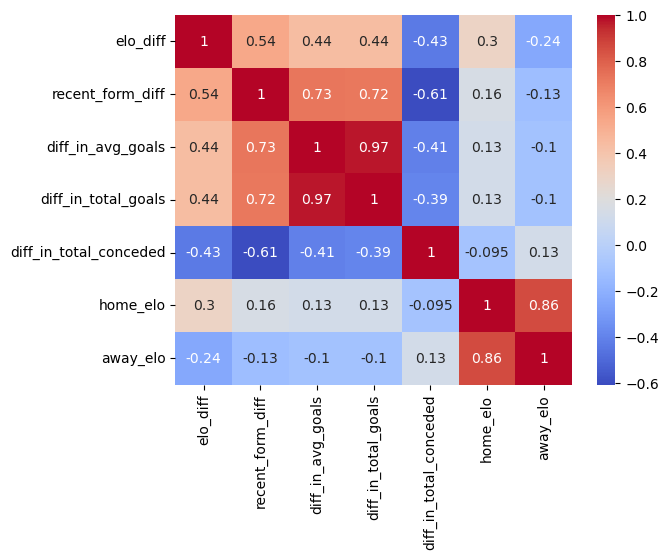

In [530]:
numeric_cols = [
    "elo_diff",
    "recent_form_diff",
    "diff_in_avg_goals",
    "diff_in_total_goals",
    "diff_in_total_conceded",
    "home_elo",
    "away_elo"
]

corr = results[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

In [531]:
# Dropping redundant columns based on the correlation analysis and domain knowledge
matches = matches.drop(columns=[
    "home_elo",
    "away_elo",
    "diff_in_total_goals"
])

## Correlation between Squad Ratings and Elo Ratings

In [532]:
# Data Preparation

# Add column for squad ratings to World Cup 2026 draw
wc2026_ratings = wc2026_draw.merge(
    squad_ratings[["country", "avg_rating"]],
    on="country",
    how="left"
)

# Filter for latest elo ratings for each country
latest_elo = elo_ratings.sort_values("rank_date").groupby("country_full").tail(1)

# Add column for Elo ratings to World Cup 2026 draw
wc2026_ratings = wc2026_ratings.merge(
    latest_elo[["country_full", "total_points"]],
    left_on="country",
    right_on="country_full",
    how="left"
).drop(columns=["country_full"]).rename(columns={"avg_rating": "squad_rating", "total_points": "elo_rating"})

wc2026_ratings

,country,group,squad_rating,elo_rating
0,Mexico,A,68.884615,1858.0
1,South Africa,A,56.423077,1524.0
2,South Korea,A,73.653846,1752.0
3,Czech Republic,A,75.538462,1726.0
4,Canada,B,71.192308,1784.0
5,Bosnia and Herzegovina,B,72.423077,1594.0
6,Qatar,B,50.000000,1425.0
7,Switzerland,B,77.653846,1889.0
8,Brazil,C,83.615385,1984.0
9,Morocco,C,76.423077,1821.0


Scatter Plot of Elo Ratings against Squad Ratings for countries participating in the 2026 World Cup.

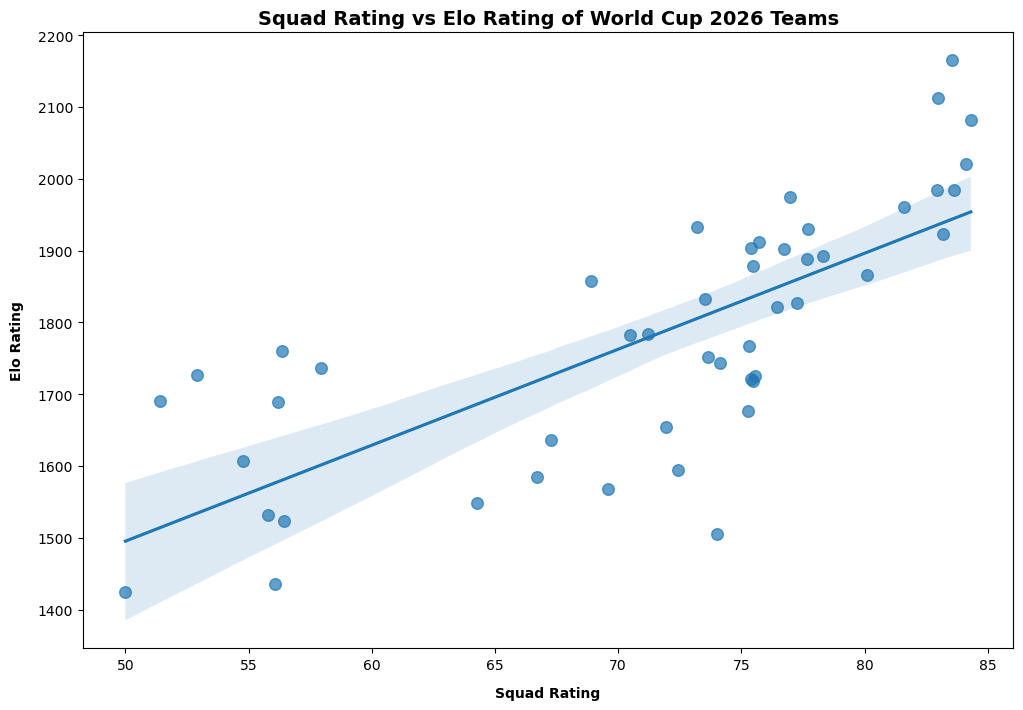

In [533]:
fig, ax = plt.subplots(figsize=(12,8))

sns.regplot(
    data=wc2026_ratings,
    x="squad_rating",
    y="elo_rating",
    scatter_kws={"s": 70, "alpha": 0.7},
    
)

plt.title(
    "Squad Rating vs Elo Rating of World Cup 2026 Teams",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Squad Rating", labelpad=10, fontweight="bold")
plt.ylabel("Elo Rating", labelpad=10, fontweight="bold")
plt.show()

# Create Final Matches Dataset

In [534]:
matches.to_csv("../data/processed/matches.csv", index=False)